# The drive

Five observers ranked, the firmware's law searched over 23-63 V, the envelope, the rotor observer on the board's model.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The plant, drawn around the 5230SL

`tools/sim/montecarlo.py` runs the firmware's C against `drive_model.c`; plants drawn around the 5230SL: R to 125 C, L +/-25 %, saliency 1.05-1.5, dead time either side. Cost `sigma_theta + speed_err + 10 trip`.

In [3]:
from tools.sim import montecarlo as mc

In [4]:
print('link sweep', mc.VDC_SWEEP)
print('knobs', {k: v[:2] for k, v in mc.KNOBS.items()})
print('I_MAX %.0f  I_TRIP %.0f  I_H_MAX %.0f  TOP %.2f  LOST %.2f rad'
      % (mc.I_MAX, mc.I_TRIP, mc.I_H_MAX, mc.TOP, mc.LOST))
plant = mc.draw(1, 43.0)
print({k: round(v, 6) for k, v in plant.items()})

link sweep (23.0, 33.0, 43.0, 53.0, 63.0)
knobs {'bw_i': (300.0, 2500.0), 'f_pll': (20.0, 400.0), 'zeta': (0.5, 1.2), 'v_inj': (0.02, 0.2), 'n_inj': (1, 4), 'w_lo': (50.0, 800.0), 'w_ratio': (1.5, 4.0), 'bw_w': (1.0, 20.0)}
I_MAX 60  I_TRIP 100  I_H_MAX 5  TOP 0.50  LOST 0.35 rad
{'r': 0.039602, 'ld': 1.8e-05, 'lq': 2.1e-05, 'lambda': 0.002071, 'pole_pairs': 14.0, 'sat': 0.3, 'i_sat': 40.0, 'j': 0.000141, 'b': 0.000253, 'load': 0.0, 'v_dt': 0.082524, 'i_knee': 11.289512, 'vdc': 43.0, 'noise': 0.355632, 'theta0': 0.178112, 'sub': 4.0, 'theta_err0': 0.805836, 'k_prop': 5e-06}


## 3 Sliding mode against flux linkage over the speed sweep

Sliding mode against flux linkage: seven speeds, five plants, 2 A. Torque at angle error `eps` is `cos(eps)`: 20 deg costs 6 %, the line.

In [5]:
import math
from coaxial.model.blocks import CurrentLoop, Plant, Signals
from coaxial.model import inverter, sensorless
from motor.catalog import PLATINUM_5230SL
from motor.pmsm import Parameters

TWO_PI = 2.0 * math.pi
motor = PLATINUM_5230SL
SPEEDS = (20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0)
PLANTS = 5
CRITERION_DEG = 20.0
#: Where the blend hands over from sliding mode to flux linkage, rad/s
#: electrical - a band about the crossover, not a threshold.
BLEND_BAND = (400.0, 1400.0)

def rpm(w_e):
    return w_e / motor.poles * 60.0 / TWO_PI

def fitted_of(plant, r_error=0.0):
    """The drawn plant as the parameters an observer is handed."""
    return Parameters(name='drawn', r=plant['r'] * (1.0 + r_error),
                      ld=plant['ld'], lq=plant['lq'], lam=plant['lambda'],
                      poles=int(plant['pole_pairs']), measured=False)

def stationary(s):
    """The dq solution and the currents rotated out to alpha-beta: what
    the board's chain gets too, there being no phase-voltage sense."""
    c, sn = math.cos(s.theta), math.sin(s.theta)
    return (s.vd * c - s.vq * sn, s.vd * sn + s.vq * c,
            s.id * c - s.iq * sn, s.id * sn + s.iq * c)

def deg_rms(errors):
    return math.degrees(math.sqrt(sum(e * e for e in errors) / len(errors)))

def observe(plant, w_e, seconds=0.4):
    """Both observers against a rotor held at w_e: degrees rms, the
    blend of the two, and each one's own residual."""
    fitted = fitted_of(plant)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    pmsm = Plant(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    pmsm.motor.omega = w_e
    smo = sensorless.SlidingModeObserver(
        fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0)
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    got = {'smo': [], 'flux': [], 'gap': [], 'blend': []}
    res = {'smo': [], 'flux': []}
    lo, hi = BLEND_BAND
    share = 0.0
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        pmsm(s, dt)
        va, vb, ia, ib = stationary(s)
        th_s = smo.update(va, vb, ia, ib, dt)
        th_f = flux.update(va, vb, ia, ib, dt)
        if s.t <= 0.5 * seconds:
            continue
        got['smo'].append(mc.wrap(th_s - s.theta))
        got['flux'].append(mc.wrap(th_f - s.theta))
        got['gap'].append(mc.wrap(th_s - th_f))
        res['smo'].append(math.hypot(smo.i_alpha - ia, smo.i_beta - ib)
                          / max(plant['noise'], 1e-3))
        psi = math.hypot(flux.psi_alpha - fitted.ld * ia,
                         flux.psi_beta - fitted.ld * ib)
        res['flux'].append(abs(psi - fitted.lam) / fitted.lam)
        # The blend, ramped over BLEND_BAND on the observer's own speed and
        # applied to the unit vectors - an angle is not a quantity you average.
        f = min(1.0, max(0.0, (abs(smo.omega) - lo) / (hi - lo)))
        x = (1.0 - f) * math.cos(th_s) + f * math.cos(th_f)
        y = (1.0 - f) * math.sin(th_s) + f * math.sin(th_f)
        got['blend'].append(mc.wrap(math.atan2(y, x) - s.theta))
        share += 1.0 - f
    out = {k: deg_rms(v) for k, v in got.items()}
    out['share'] = share / len(got['blend'])
    out['res_smo'] = sum(res['smo']) / len(res['smo'])
    out['res_flux'] = sum(res['flux']) / len(res['flux'])
    return out

def median(values):
    return values[len(values) // 2]

plants = [mc.draw(90 + i, 43.0) for i in range(PLANTS)]
table = {}                      # rad/s electrical -> each measure over the plants, sorted
print('deg rms over %d drawn plants, iq 2 A; the residuals are the median plant' % PLANTS)
print('  rad/s el    rpm   SMO deg rms   resid    flux deg rms   wc/w   |psi|   apart')
print('                   median  worst  sigma_i  median  worst    deg   off %     deg')
for w_e in SPEEDS:
    rows = [observe(p, w_e) for p in plants]
    row = table[w_e] = {k: sorted(r[k] for r in rows) for k in rows[0]}
    print('%10.0f %6.0f %9.1f %6.1f %8.2f %9.1f %6.1f %7.1f %7.1f %7.1f'
          % (w_e, rpm(w_e), median(row['smo']), row['smo'][-1],
             median(row['res_smo']), median(row['flux']), row['flux'][-1],
             math.degrees(math.atan2(20.0, w_e)), 100.0 * median(row['res_flux']),
             median(row['gap'])))

def band_of(which):
    """(lowest, highest) swept speed whose worst plant is inside the
    criterion; nan and nan when none is."""
    inside = [w for w, row in table.items() if row[which][-1] <= CRITERION_DEG]
    return (min(inside), max(inside)) if inside else (math.nan, math.nan)

print()
for which, name in (('smo', 'sliding mode'), ('flux', 'flux linkage'),
                    ('blend', 'the two blended')):
    lo, hi = band_of(which)
    print('%-15s inside %.0f deg from %5.0f to %5.0f rad/s = %4.0f to %5.0f rpm'
          % (name, CRITERION_DEG, lo, hi, rpm(lo), rpm(hi)))

deg rms over 5 drawn plants, iq 2 A; the residuals are the median plant
  rad/s el    rpm   SMO deg rms   resid    flux deg rms   wc/w   |psi|   apart
                   median  worst  sigma_i  median  worst    deg   off %     deg


        20     14      18.5   19.6     3.64      52.9   53.0    45.0    30.7    55.1


        50     34       7.4    7.8     3.93      36.0   36.1    21.8     7.8    36.4


       100     68       4.3    4.8     4.57      23.3   23.3    11.3     2.1    23.4


       200    136       2.7    3.0     5.86      12.0   12.0     5.7     0.8    11.9


       500    341       2.2    2.2    10.47       5.4    5.4     2.3     0.7     5.7


      1000    682       3.0    3.1    17.78       3.5    3.5     1.1     0.6     4.9


      2000   1364       5.5    5.7    33.82       3.2    3.3     0.6     0.6     7.4

sliding mode    inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm
flux linkage    inside 20 deg from   200 to  2000 rad/s =  136 to  1364 rpm
the two blended inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm


Each adds its filter's lag back on its own speed: sliding mode's low-pass `atan(w/wc)`, 76 deg at 2000 rad/s (`wc` 500); the flux integrator's leak `atan(wc/w)`, 45 deg at `w = wc` = 20 rad/s (the `wc/w` column).

## 4 The second inductance

`psi - L i` with one L leaves `(Lq - Ld) iq` on q: an error that grows with load. The extended back-EMF `E_ex` has none. `FluxObserver` is the plain form (SPM: the same).

In [6]:
print('what one L costs the plain flux observer under load, 5230SL')
print('Ld %.1f uH, Lq %.1f uH, saliency %.2f, lambda %.5f Wb'
      % (motor.ld * 1e6, motor.lq * 1e6, motor.saliency, motor.lam))
print()
print('   iq A   (Lq-Ld) iq uWb   angle error deg   torque lost %')
for iq in (0.0, 2.0, 10.0, 30.0, 60.0, 100.0):
    stray = (motor.lq - motor.ld) * iq
    err = math.atan2(stray, motor.lam)
    print('%7.0f %17.1f %17.2f %13.1f'
          % (iq, stray * 1e6, math.degrees(err), 100.0 * (1.0 - math.cos(err))))

what one L costs the plain flux observer under load, 5230SL
Ld 22.0 uH, Lq 29.0 uH, saliency 1.32, lambda 0.00207 Wb

   iq A   (Lq-Ld) iq uWb   angle error deg   torque lost %
      0               0.0              0.00           0.0
      2              14.0              0.39           0.0
     10              70.0              1.93           0.1
     30             210.0              5.79           0.5
     60             420.0             11.46           2.0
    100             700.0             18.66           5.3


## 5 Five observers, ranked by measurement

ESO (`wo` stable to ~12 000 rad/s at a 20 us step), Luenberger (R adaptation off, `gamma` 0), dual flux with a PLL (no lag, no leak). Same plants and current; a 20 us step, half the sweep's. Ranked by the worst speed.

In [7]:
OBSERVERS = ('dual', 'smo', 'luen', 'eso', 'flux')

def five(fitted, w_e):
    """One of each, with the states a running drive would hand over."""
    made = {
        'eso': sensorless.ExtendedStateObserver(fitted.r, fitted.ld, wo=12000.0),
        'luen': sensorless.AdaptiveLuenberger(fitted.r, fitted.ld),
        'dual': sensorless.DualFluxObserver(fitted.r, fitted.ld, fitted.lam,
                                            cross=20.0),
        'smo': sensorless.SlidingModeObserver(
            fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0),
        'flux': sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0),
    }
    for one in made.values():
        one.omega = w_e
    return made

def compare(plant, w_e, seconds=1.0, iq=2.0):
    """All five against a rotor held at w_e. Degrees rms."""
    fitted = fitted_of(plant)
    dt = inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    pmsm = Plant(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    pmsm.motor.omega = w_e
    made = five(fitted, w_e)
    s = Signals()
    s.iq_ref = iq
    err = {k: [] for k in made}
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        pmsm(s, dt)
        va, vb, ia, ib = stationary(s)
        for name, one in made.items():
            th = one.update(va, vb, ia, ib, dt)
            if s.t > 0.5 * seconds:
                err[name].append(mc.wrap(th - s.theta))
    return {k: deg_rms(v) for k, v in err.items()}

medians = []                    # one dict a speed: observer -> median deg rms
print('deg rms, median of %d plants, iq 2 A' % PLANTS)
print('  rad/s el    rpm ' + ''.join('%8s' % n for n in OBSERVERS))
for w_e in (20.0, 100.0, 500.0, 2000.0):
    rows = [compare(p, w_e) for p in plants]
    got = {name: median(sorted(r[name] for r in rows)) for name in OBSERVERS}
    medians.append(got)
    print('%10.0f %6.0f ' % (w_e, rpm(w_e)) + ''.join('%8.1f' % got[n] for n in OBSERVERS))
print()
RANKED = sorted(OBSERVERS, key=lambda n: max(g[n] for g in medians))
for name in RANKED:
    print('%-6s %5.1f deg at its best, %5.1f at its worst'
          % (name, min(g[name] for g in medians), max(g[name] for g in medians)))

deg rms, median of 5 plants, iq 2 A
  rad/s el    rpm     dual     smo    luen     eso    flux


        20     14      0.7     8.9    84.0    61.2    52.6


       100     68      0.7     2.0    26.5    11.0    23.1


       500    341      1.1     1.0     4.7     4.9     5.2


      2000   1364      3.5     2.5     1.8    17.0     2.4

dual     0.7 deg at its best,   3.5 at its worst
smo      1.0 deg at its best,   8.9 at its worst
flux     2.4 deg at its best,  52.6 at its worst
eso      4.9 deg at its best,  61.2 at its worst
luen     1.8 deg at its best,  84.0 at its worst


Dual flux + PLL wins; sliding mode is solid; Luenberger's R and back-EMF share one residual, so R stays fixed; the ESO is limited by the 20 us Euler step.

## 6 The hybrid

Switch, blend over a band (the firmware's shape), or weight on residuals. The cost against the board's drive step: 2 922 of 9 500 cycles a period (FINDINGS).

In [8]:
STEP_CYCLES = 2922                          # the board's drive step, CYCCNT (FINDINGS)
PERIOD_CYCLES = int(round(475e6 * inverter.TS))

print('the blend, %.0f to %.0f rad/s = %.0f to %.0f rpm'
      % (BLEND_BAND[0], BLEND_BAND[1], rpm(BLEND_BAND[0]), rpm(BLEND_BAND[1])))
print('  rad/s el    rpm   SMO share   blend deg rms   best single   gained')
for w_e, row in table.items():
    single = min(median(row['smo']), median(row['flux']))
    got = median(row['blend'])
    print('%10.0f %6.0f %10.2f %14.1f %13.1f %8.1f %%'
          % (w_e, rpm(w_e), median(row['share']), got, single,
             100.0 * (single - got) / single))
print()
print("cost, per step, against the drive step's own %d cycles of %d:" % (STEP_CYCLES, PERIOD_CYCLES))
print('   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2')
print('   flux linkage   2 integrators, one atan2, a sqrt and an atan')
print('   the blend      one ramp, two multiplies, one atan2')
print('   headroom       %d cycles a period at %.0f kHz'
      % (PERIOD_CYCLES - STEP_CYCLES, 1e-3 / inverter.TS))

the blend, 400 to 1400 rad/s = 273 to 955 rpm
  rad/s el    rpm   SMO share   blend deg rms   best single   gained
        20     14       1.00           18.5          18.5      0.0 %
        50     34       1.00            7.4           7.4      0.0 %
       100     68       1.00            4.3           4.3      0.0 %
       200    136       1.00            2.7           2.7      0.0 %
       500    341       0.90            2.1           2.2      4.2 %
      1000    682       0.40            2.2           3.0     25.1 %
      2000   1364       0.00            3.2           3.2      0.0 %

cost, per step, against the drive step's own 2922 cycles of 9500:
   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2
   flux linkage   2 integrators, one atan2, a sqrt and an atan
   the blend      one ramp, two multiplies, one atan2
   headroom       6578 cycles a period at 50 kHz


## 7 What the flux magnitude says about the magnets

The flux magnitude is lambda - the magnets. R error lands in it, worst at low speed: one plant, R exact and +/-30 %.

In [9]:
def identify_lambda(plant, w_e, r_error=0.0, seconds=0.4):
    """What the flux observer's magnitude says lambda is, with R off by
    `r_error` as a fraction: the estimate over the truth."""
    fitted, truth = fitted_of(plant, r_error), fitted_of(plant)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    pmsm = Plant(truth, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    pmsm.motor.omega = w_e
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    seen = []
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        pmsm(s, dt)
        va, vb, ia, ib = stationary(s)
        flux.update(va, vb, ia, ib, dt)
        if s.t > 0.5 * seconds:
            seen.append(math.hypot(flux.psi_alpha - fitted.ld * ia,
                                   flux.psi_beta - fitted.ld * ib))
    return (sum(seen) / len(seen)) / truth.lam

recovered = {}
print('lambda recovered from |psi_r|, as a fraction of the truth')
print('  rad/s el    rpm    R exact   R +30 %   R -30 %')
for w_e in SPEEDS:
    recovered[w_e] = [identify_lambda(plants[0], w_e, e) for e in (0.0, 0.3, -0.3)]
    print('%10.0f %6.0f %10.3f %9.3f %9.3f' % ((w_e, rpm(w_e)) + tuple(recovered[w_e])))

lambda recovered from |psi_r|, as a fraction of the truth
  rad/s el    rpm    R exact   R +30 %   R -30 %


        20     14      0.695     0.317     1.072


        50     34      0.923     0.725     1.121


       100     68      0.979     0.874     1.084


       200    136      0.994     0.941     1.048


       500    341      0.999     0.978     1.020


      1000    682      1.000     0.989     1.010


      2000   1364      1.000     0.994     1.005


## 8 The firmware's law over the link sweep

Per link: a Latin hypercube, then a half-box about the best three; `min_rpm` is where back-EMF alone lost the rotor. Small here; the tool's 48 x 16 x 24.

In [10]:
import contextlib
import io
import os
import time

VDCS = (23.0, 43.0, 63.0)
DRAWS = 2
t0 = time.perf_counter()
with mc.pool() as p, contextlib.redirect_stdout(io.StringIO()):
    best, runs = mc.search(p, vdcs=VDCS, candidates_n=6, draws=DRAWS, refine=3)
    checked = mc.verify(p, best, draws=4)
print('%d runs in the search, %d in the verification, %.0f s on %d cores'
      % (len(runs), len(checked), time.perf_counter() - t0, os.cpu_count()))
print('draws per point  %d plants, each drawn around the 5230SL' % DRAWS)
print('cost             sigma_theta + speed_err + 10 x trip')
verified = checked.query('not bemf_only')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = verified[verified.vdc == vdc]
    print('%4.0f V  robust %.3f  bw_i %6.0f Hz  f_pll %5.0f Hz  zeta %.2f  v_inj %.3f  n_inj %d'
          % (vdc, row.robust, row.bw_i, row.f_pll, row.zeta, row.v_inj, int(row.n_inj)))
    print('        verified sigma_theta %.4f rad (%.2f deg), trips %d of %d'
          % (sub.sigma_theta.mean(), math.degrees(sub.sigma_theta.mean()),
             int(sub.trip.sum()), len(sub)))
floor = checked.query('bemf_only').groupby('vdc')['min_rpm'].agg(['mean', 'max', 'count'])
print()
print('the sensorless floor: rpm where the back-EMF alone lost the rotor')
print(floor.round(0))
print('trips with injection: %d of %d' % (int(verified.trip.sum()), len(verified)))

54 runs in the search, 24 in the verification, 5 s on 16 cores
draws per point  2 plants, each drawn around the 5230SL
cost             sigma_theta + speed_err + 10 x trip
  23 V  robust 0.084  bw_i   1187 Hz  f_pll    83 Hz  zeta 0.53  v_inj 0.200  n_inj 1
        verified sigma_theta 0.0388 rad (2.22 deg), trips 0 of 4
  43 V  robust 0.095  bw_i    948 Hz  f_pll    50 Hz  zeta 0.50  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0475 rad (2.72 deg), trips 0 of 4
  63 V  robust 0.121  bw_i    948 Hz  f_pll    50 Hz  zeta 0.50  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0766 rad (4.39 deg), trips 0 of 4

the sensorless floor: rpm where the back-EMF alone lost the rotor
      mean   max  count
vdc                    
23.0  31.0  35.0      4
43.0  10.0  22.0      4
63.0  14.0  30.0      4
trips with injection: 0 of 12


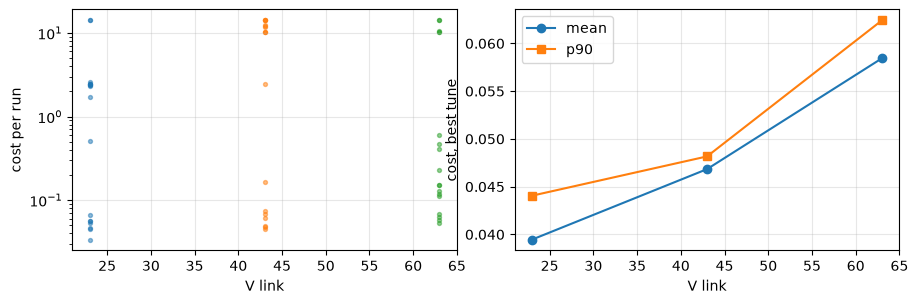

In [11]:
from coaxial.draw.figures import figure, show

fig, (a, b) = figure(rows=1, cols=2)
for vdc in VDCS:
    sub = runs[runs.vdc == vdc]
    a.scatter([vdc] * len(sub), sub.cost, s=8, alpha=0.5)
a.set_xlabel('V link')
a.set_ylabel('cost per run')
a.set_yscale('log')
b.plot(best.vdc, best['mean'], 'o-', label='mean')
b.plot(best.vdc, best.p90, 's-', label='p90')
b.set_xlabel('V link')
b.set_ylabel('cost, best tune')
b.legend()
show(fig)

No-load speed `V_FRAC Vdc/sqrt(3) / lambda`, `V_FRAC` 0.95. With an APC20x10E: where `k w^2` meets the current ceiling, or no-load, whichever first.

In [12]:
from motor.catalog import KT_NM_PER_AMP, RATINGS
from motor.loads import APC20x10E

I_RATING = 100.0                    # the board, instantaneous
kt = 1.5 * motor.poles * motor.lam
print('Kt               %.4f N.m/A  (the sheet: %.4f)' % (kt, KT_NM_PER_AMP))
print('board rating     %.0f A instantaneous, %.0f V link' % (I_RATING, max(mc.VDC_SWEEP)))
print('motor rating     %.1f A burst for %.0f s, %.0f W'
      % (RATINGS['i_max'], RATINGS['t_i_max'], RATINGS['p_max']))
print('the limit        %s' % ('the inverter' if I_RATING < RATINGS['i_max'] else 'the motor'))
print()
print('with an APC20x10E on the shaft, the operating point:')
print('link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by')
operating = {}
for vdc in (23.0, 33.0, 43.0, 53.0, 63.0):
    w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam
    no_load = w_e / motor.poles
    by_current = math.sqrt(kt * I_RATING / APC20x10E.k)
    wm = min(by_current, no_load)
    torque = APC20x10E.k * wm * wm
    operating[vdc] = (no_load * 60.0 / TWO_PI, wm * 60.0 / TWO_PI, torque)
    print('%4.0f V %10.0f %11.0f %7.2f %10.2f %7.1f %12.1f   %s'
          % (vdc, no_load * 60.0 / TWO_PI, wm * 60.0 / TWO_PI, torque,
             torque * wm / 1000.0, torque / kt, torque / kt / math.sqrt(2.0),
             'the link' if wm < by_current else 'the 100 A rating'))
print()
print('what the search chose, and what it implies:')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = verified[verified.vdc == vdc]
    top_rpm = rpm(inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam)
    print('%4.0f V' % vdc)
    print('   current loop   %.0f Hz of the %.0f Hz two periods of delay allow'
          % (row.bw_i, 50e3 * 0.05))
    print('   observer       %.0f Hz, zeta %.2f' % (row.f_pll, row.zeta))
    print('   injection      %.0f Hz at %.1f %% of Vdc/sqrt3, %d period(s)'
          % (50e3 / (2.0 * int(row.n_inj)), 100.0 * row.v_inj, int(row.n_inj)))
    print('   blend          %.0f to %.0f rad/s electrical = %.0f to %.0f rpm'
          % (row.w_lo, row.w_lo * row.w_ratio, rpm(row.w_lo), rpm(row.w_lo * row.w_ratio)))
    print('   held           sigma_theta %.2f deg electrical, %.3f deg mechanical'
          % (math.degrees(sub.sigma_theta.mean()),
             math.degrees(sub.sigma_theta.mean()) / motor.poles))
    print('   back-EMF alone loses the rotor at %.0f rpm = %.1f %% of the %.0f rpm this link holds'
          % (floor.loc[vdc, 'mean'], 100.0 * floor.loc[vdc, 'mean'] / top_rpm, top_rpm))

Kt               0.0435 N.m/A  (the sheet: 0.0435)
board rating     100 A instantaneous, 63 V link
motor rating     112.5 A burst for 42 s, 4985 W
the limit        the inverter

with an APC20x10E on the shaft, the operating point:
link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by
  23 V       4151        4151    0.97       0.42    22.3         15.8   the link
  33 V       5956        5956    2.00       1.25    46.0         32.5   the link
  43 V       7762        7762    3.40       2.76    78.1         55.2   the link
  53 V       9566        8785    4.35       4.00   100.0         70.7   the 100 A rating
  63 V      11371        8785    4.35       4.00   100.0         70.7   the 100 A rating

what the search chose, and what it implies:
  23 V
   current loop   1187 Hz of the 2500 Hz two periods of delay allow
   observer       83 Hz, zeta 0.53
   injection      25000 Hz at 20.0 % of Vdc/sqrt3, 1 period(s)
   blend          127 to 195 rad/s electrical = 

## 9 Speed and torque against the tolerances

Lambda +/-10 %: speed as `1/lambda`, torque as `lambda`. 100 A is the board's; continuous torque the thermal network's, at the throttle point: 90 % of the span from 25 to 125 C, 115 C.

In [13]:
from coaxial.devices.thermal import THROTTLE_AT
from coaxial.model import thermal

LAMBDA_SPREAD = (0.9, 1.1)          # what mc.draw draws over
R_PHASE = inverter.RDS_ON + inverter.SHUNT
CEILING_C = thermal.ceiling_of('phase_u', THROTTLE_AT)   # the record's throttle point
AMBIENT_C = thermal.AMBIENT
capacity = thermal.CFG['capacity']

def spread(f):
    """(min, max) of f over the lambda tolerance."""
    got = [f(motor.lam * s) for s in LAMBDA_SPREAD]
    return min(got), max(got)

def no_load_rpm(vdc, lam):
    return rpm(inverter.V_FRAC * vdc / math.sqrt(3.0) / lam)

print('link   no-load rpm            torque at 100 A       shaft kW at that torque')
print('         min    max            min     max            min     max')
for vdc in VDCS:
    speeds = spread(lambda lam: no_load_rpm(vdc, lam))
    torques = spread(lambda lam: 1.5 * motor.poles * lam * I_RATING)
    def shaft_kw(lam, vdc=vdc):
        # At the propeller's operating point, not at both ceilings at once.
        kt_l = 1.5 * motor.poles * lam
        wm = min(math.sqrt(kt_l * I_RATING / APC20x10E.k),
                 inverter.V_FRAC * vdc / math.sqrt(3.0) / lam / motor.poles)
        return APC20x10E.k * wm ** 3 / 1000.0
    powers = spread(shaft_kw)
    print('%4.0f V %7.0f %6.0f %14.2f %7.2f %14.2f %7.2f'
          % ((vdc,) + speeds + torques + powers))
print()
i_rms = thermal.continuous_amps(R_PHASE, CEILING_C)
iq_cont = i_rms * math.sqrt(2.0)
print('continuous, worst node at the %.1f C throttle point:' % CEILING_C)
print('   %.1f A rms a phase = %.1f A of iq = %.2f N.m' % (i_rms, iq_cont, kt * iq_cont))
print()
print('burst from ambient, the faster of the FET node (%.3f J/K) and the shunt node (%.2f J/K):'
      % (capacity['driver_u'], capacity['phase_u']))
print('   iq A   A rms   W FET   W shunt   K/s      s to the ceiling')
def slope(power):
    """K/s of the faster node: `phase_power` splits the conduction between the two."""
    return max(power[n] / capacity[n] for n in ('driver_u', 'phase_u'))
def burst_s(iq):
    return (CEILING_C - AMBIENT_C) / slope(thermal.phase_power(iq / math.sqrt(2.0), R_PHASE))
for iq in (20.0, 40.0, 60.0, 100.0):
    p = thermal.phase_power(iq / math.sqrt(2.0), R_PHASE)
    print('%7.0f %7.1f %7.1f %9.1f %5.1f %21.2f'
          % (iq, iq / math.sqrt(2.0), p['driver_u'], p['phase_u'], slope(p), burst_s(iq)))

link   no-load rpm            torque at 100 A       shaft kW at that torque
         min    max            min     max            min     max
  23 V    3774   4613           3.92    4.79           0.32    0.58
  43 V    7056   8624           3.92    4.79           2.07    3.42
  63 V   10338  12635           3.92    4.79           3.42    4.62

continuous, worst node at the 115.0 C throttle point:
   20.0 A rms a phase = 28.3 A of iq = 1.23 N.m

burst from ambient, the faster of the FET node (0.117 J/K) and the shunt node (0.40 J/K):
   iq A   A rms   W FET   W shunt   K/s      s to the ceiling
     20    14.1     0.6       0.7   4.8                 18.75
     40    28.3     1.6       2.8  14.1                  6.40
     60    42.4     3.4       6.3  29.5                  3.05
    100    70.7     9.2      17.5  78.9                  1.14


In [14]:
top = spread(lambda lam: no_load_rpm(63.0, lam))
low = spread(lambda lam: no_load_rpm(23.0, lam))
peak = spread(lambda lam: 1.5 * motor.poles * lam * I_RATING)
cont = spread(lambda lam: 1.5 * motor.poles * lam * iq_cont)
smo_rpm, flux_rpm = rpm(band_of('smo')[0]), rpm(band_of('flux')[0])
bemf_rpm = floor.loc[43.0, 'mean']
held = (math.degrees(verified.sigma_theta.min()), math.degrees(verified.sigma_theta.max()))

print('%-34s %.0f to %.0f rpm at 63 V' % ('MAXIMUM SPEED, no load', *top))
print('%-34s %.0f to %.0f rpm at 23 V' % ('', *low))
print('%-34s 0 rpm - it holds at rest' % 'MINIMUM SPEED, injection')
print('%-34s %.0f rpm, 43 V' % ('   back-EMF alone, firmware', bemf_rpm))
print('%-34s %.0f rpm' % ('   sliding mode, 20 deg', smo_rpm))
print('%-34s %.0f rpm' % ('   flux linkage, 20 deg', flux_rpm))
print('%-34s %.2f to %.2f N.m' % ('PEAK TORQUE, 100 A instantaneous', *peak))
print('%-34s %.2f to %.2f N.m (%.1f A of iq)' % ('CONTINUOUS TORQUE, thermal', *cont, iq_cont))
print('%-34s %.2f s at 100 A, %.2f s at 60 A'
      % ('BURST TO THE THROTTLE POINT', burst_s(100.0), burst_s(60.0)))
print('%-34s %.1f to %.1f deg electrical' % ('ANGLE ERROR, injection held', *held))

MAXIMUM SPEED, no load             10338 to 12635 rpm at 63 V
                                   3774 to 4613 rpm at 23 V
MINIMUM SPEED, injection           0 rpm - it holds at rest
   back-EMF alone, firmware        10 rpm, 43 V
   sliding mode, 20 deg            14 rpm
   flux linkage, 20 deg            136 rpm
PEAK TORQUE, 100 A instantaneous   3.92 to 4.79 N.m
CONTINUOUS TORQUE, thermal         1.11 to 1.35 N.m (28.3 A of iq)
BURST TO THE THROTTLE POINT        1.14 s at 100 A, 3.05 s at 60 A
ANGLE ERROR, injection held        1.8 to 6.6 deg electrical


## 10 A low-saliency motor

Saliency 1.05-1.5: `choose_injection` at this AFE's floor, `decide` at 10 dB, with 5 A and with 1 A of HF current.

In [15]:
sigma_i = max(inverter.NOISE_A)
loop_hz = sensorless.current_loop(motor.r, motor.ld, 1.0 / inverter.TS, sigma_i, 43.0)['bw_hz']
print('             ---- 5 A of HF headroom ----   ---- 1 A ----')
print('saliency   SNR dB   method    i_h peak A   SNR dB   method')
methods = {}
for ratio in (1.02, 1.05, 1.15, 1.32, 1.5):
    wide, tight = (sensorless.choose_injection(
        motor.ld, motor.ld * ratio, sigma_i, 1.0 / inverter.TS, 50.0, 43.0,
        i_h_max=cap, bw_i_hz=loop_hz) for cap in (5.0, 1.0))
    if wide is None or tight is None:
        print('%8.2f   nothing fits' % ratio)
        continue
    methods[ratio] = (wide['i_h_peak'], sensorless.decide(wide['snr_db']),
                      sensorless.decide(tight['snr_db']))
    print('%8.2f %8.1f   %-9s %10.2f %8.1f   %-9s'
          % (ratio, wide['snr_db'], methods[ratio][1], wide['i_h_peak'],
             tight['snr_db'], methods[ratio][2]))
print()
print('the 5230SL sits at %.2f, sigma_i %.2f A rms' % (motor.saliency, sigma_i))
print()
hand_over, second = band_of('smo')[0], band_of('flux')[0]
print('CONTROL STRATEGY, low saliency')
print('   below the hand-over      I/f ramp on current, saturation pulse for polarity')
print('   hand-over at             %.0f rad/s = %.0f rpm, the sliding-mode floor'
      % (hand_over, rpm(hand_over)))
print('   w_lo .. w_hi             %.0f .. %.0f rad/s, blended not switched'
      % (hand_over, 2.0 * hand_over))
print('   to flux linkage          inside %.0f deg from %.0f rad/s = %.0f rpm, blended in'
      % (CRITERION_DEG, second, rpm(second)))
print('                            on speed over BLEND_BAND, %.0f .. %.0f rad/s' % BLEND_BAND)
print('   current loop             %.0f Hz, a twentieth of %.0f kHz sampling'
      % (loop_hz, 1e-3 / inverter.TS))
print('   injection                clears 10 dB to saliency %.2f here; the cost is'
      % min(r for r, m in methods.items() if m[1] == 'injection'))
print('                            HF current, so i_h_max is the knob')
print()
print('THERMAL OBSERVER')
print('   node ceilings            %.0f C the silicon, %.0f C the laminate'
      % (thermal.CEILING_DEFAULT_C, thermal.CEILING_C['board']))
print('   throttle at              %.0f %% = %.1f C, derating to the ceiling; a trip drops MOE'
      % (100.0 * THROTTLE_AT, CEILING_C))
print('   continuous               %.1f A rms a phase = %.2f N.m' % (i_rms, kt * iq_cont))
print('   burst                    timed, not held: %.1f s at 100 A from ambient' % burst_s(100.0))
print('   sample the NTC every     30 s, against a board constant of %.1f min'
      % thermal.tau_minutes())
print('   re-fit first             the phase node to_board, with current flowing')

             ---- 5 A of HF headroom ----   ---- 1 A ----
saliency   SNR dB   method    i_h peak A   SNR dB   method
    1.02     10.7   injection       2.26      3.6   if_start 
    1.05     18.4   injection       2.26     11.3   injection
    1.15     20.0   injection       0.99     20.0   injection
    1.32     20.0   injection       0.53     20.0   injection
    1.50     20.0   injection       0.39     20.0   injection

the 5230SL sits at 1.32, sigma_i 0.41 A rms

CONTROL STRATEGY, low saliency
   below the hand-over      I/f ramp on current, saturation pulse for polarity
   hand-over at             20 rad/s = 14 rpm, the sliding-mode floor
   w_lo .. w_hi             20 .. 40 rad/s, blended not switched
   to flux linkage          inside 20 deg from 200 rad/s = 136 rpm, blended in
                            on speed over BLEND_BAND, 400 .. 1400 rad/s
   current loop             2500 Hz, a twentieth of 50 kHz sampling
   injection                clears 10 dB to saliency 1.02 here;

## 11 The observers against the motor this board drives

No phase-voltage sense: the voltage is the commanded duty against the measured DC link. The five observers and the firmware's chain (dual flux < 800, flux > 3000 rad/s).

In [16]:
FULL = (20.0, 100.0, 500.0, 2000.0, 5000.0, 10000.0, 15000.0)
CHAIN_BAND = (800.0, 3000.0)
VDC_TOP = 63.0
ORDER = ('chain', 'dual', 'smo', 'flux', 'luen', 'eso')

def sweep_all(plant, w_e, seconds=0.6, iq=2.0):
    """Every observer and the chain, one held speed. Degrees rms."""
    fitted = fitted_of(plant)
    dt = inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    pmsm = Plant(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    pmsm.motor.omega = w_e
    made = five(fitted, w_e)
    lo, hi = CHAIN_BAND
    s = Signals()
    s.iq_ref = iq
    err = {k: [] for k in ORDER}
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        pmsm(s, dt)
        va, vb, ia, ib = stationary(s)
        angles = {n: o.update(va, vb, ia, ib, dt) for n, o in made.items()}
        g = min(1.0, max(0.0, (abs(made['dual'].omega) - lo) / (hi - lo)))
        x = (1.0 - g) * math.cos(angles['dual']) + g * math.cos(angles['flux'])
        y = (1.0 - g) * math.sin(angles['dual']) + g * math.sin(angles['flux'])
        angles['chain'] = math.atan2(y, x)
        if s.t > 0.5 * seconds:
            for n in ORDER:
                err[n].append(mc.wrap(angles[n] - s.theta))
    return {n: (math.nan if any(e != e for e in v) else deg_rms(v))
            for n, v in err.items()}

tall = [mc.draw(90 + i, VDC_TOP) for i in range(PLANTS)]
grid = []
print('angle error deg rms, median of %d plants, %.0f V link' % (PLANTS, VDC_TOP))
print('  rad/s el     rpm ' + ''.join('%7s' % n for n in ORDER))
for w_e in FULL:
    rows = [sweep_all(p, w_e) for p in tall]
    got = {name: median(sorted(r[name] for r in rows)) for name in ORDER}
    grid.append((w_e, got))
    print('%10.0f %7.0f ' % (w_e, rpm(w_e)) + ''.join('%7.1f' % got[n] for n in ORDER))

angle error deg rms, median of 5 plants, 63 V link
  rad/s el     rpm   chain   dual    smo   flux   luen    eso


        20      14     0.5    0.5    8.9   52.5   84.1   61.4


       100      68     0.6    0.6    2.0   23.1   25.9   11.0


       500     341     1.1    1.1    1.0    5.2    4.7    4.9


      2000    1364     2.9    3.5    2.5    2.4    1.8   17.0


      5000    3410     3.0    8.2    6.2    3.0    4.9   41.0


     10000    6821     4.9   16.1   12.3    4.9   23.9   74.1


     15000   10231     7.0   24.0   18.8    7.0  162.0   98.0


In [17]:
TOP_RAD_S = inverter.V_FRAC * VDC_TOP / math.sqrt(3.0) / motor.lam

def band(name):
    inside = [w for w, got in grid if got[name] <= CRITERION_DEG]
    return (min(inside), max(inside)) if inside else (None, None)

print('WHAT THE BOARD MEASURES')
print('%-14s %-9s %13s   %s' % ('channel', 'unit', 'per count', 'floor'))
print('%-14s %-9s %13.5f   %s A rms measured'
      % ('Phase U/V/W', 'A', inverter.AFE_A_PER_COUNT, inverter.NOISE_A))
print('%-14s %-9s %13.6f   78.15 V full scale, 49.9k/2.2k' % ('DC bus', 'V', 78.15 / 65536))
print('%-14s %-9s %13s   30 mK, %.2f of the V leg\'s rise over the board'
      % ('NTC', 'centi-C', '-', thermal.NTC_SEES_DRIVERS))
print('%-14s %-9s %13s   0.125 K, reset by every AFE cycle' % ('A1335 TSEN', 'K/8', '-'))
print('%-14s %-9s %13s   the die itself, 810.5 ADC cycles' % ('MCU VSENSE', 'C', '-'))
print('   not measured: phase voltage (duty x DC link), rotor angle (only with a')
print('   magnet at the A1335), torque (Kt x iq, and Kt is the sheet, not a stand)')
print()
print('THE OBSERVERS AGAINST THE MOTOR THIS BOARD DRIVES')
print('%-7s %15s %10s %9s %13s' % ('', 'holds rpm', 'worst deg', 'torque', 'of the range'))
grip = {}
for name in ORDER:
    lo, hi = band(name)
    if lo is None:
        print('%-7s %15s' % (name, 'nowhere inside %.0f deg' % CRITERION_DEG))
        continue
    worst = max(got[name] for w, got in grid if lo <= w <= hi)
    grip[name] = (rpm(lo), rpm(hi), worst, 100.0 * math.cos(math.radians(worst)))
    print('%-7s %6.0f - %6.0f %10.1f %8.1f %% %11.0f %%'
          % (name, rpm(lo), rpm(hi), worst, grip[name][3], 100.0 * (hi - lo) / TOP_RAD_S))
print()
print('THE MOTOR, IN WHAT THE BOARD READS')
accel = kt * I_RATING / motor.j
print('%-20s %.1f V on channel 5' % ('link, measured', VDC_TOP))
print('%-20s %.0f rpm, V_FRAC Vdc/sqrt3 over lambda' % ('no-load speed', rpm(TOP_RAD_S)))
print('%-20s %.0f A on the phase channels = %.2f N.m at Kt %.4f'
      % ('peak current', I_RATING, kt * I_RATING, kt))
print('%-20s %.1f A rms a phase = %.2f N.m, the thermal ceiling'
      % ('continuous', i_rms, kt * iq_cont))
print('%-20s %.0f rad/s2 = %.0f rpm/s at the peak' % ('acceleration', accel, rpm(accel * motor.poles)))
print('%-20s %.3f s from rest to %.0f rpm, unloaded'
      % ('so the sweep takes', TOP_RAD_S / motor.poles / accel, rpm(TOP_RAD_S)))
print()
print('WHAT THE BOARD WOULD SEE IF AN OBSERVER SLIPPED')
print('   iq for the torque  rises as 1/cos(error), on the phase channels')
print('   DC link           the power rises with it, and the link sags')
print('   the drive window  eps sd and rho, op 5, and no reference needed')
print('   the NTC           minutes later, on the board time constant')

WHAT THE BOARD MEASURES
channel        unit          per count   floor
Phase U/V/W    A               0.00317   (0.35, 0.41) A rms measured
DC bus         V              0.001192   78.15 V full scale, 49.9k/2.2k
NTC            centi-C               -   30 mK, 0.30 of the V leg's rise over the board
A1335 TSEN     K/8                   -   0.125 K, reset by every AFE cycle
MCU VSENSE     C                     -   the die itself, 810.5 ADC cycles
   not measured: phase voltage (duty x DC link), rotor angle (only with a
   magnet at the A1335), torque (Kt x iq, and Kt is the sheet, not a stand)

THE OBSERVERS AGAINST THE MOTOR THIS BOARD DRIVES
              holds rpm  worst deg    torque  of the range
chain       14 -  10231        7.0     99.3 %          90 %
dual        14 -   6821       16.1     96.1 %          60 %
smo         14 -  10231       18.8     94.7 %          90 %
flux       341 -  10231        7.0     99.3 %          87 %
luen       341 -   3410        4.9     99.6 %      

## 12 The rotor observer on the board's own model

On the model the true angle is known: `theta_hat` and `theta` in one reply (two are 15 ms apart). 0.05 A spins the unloaded rotor; 20 Hz polls for 4 s.

In [18]:
drive = device.drive
drive.configure(source='model')
print(drive.model.configure(j=2e-5, b=1e-5, load=0.0, noise=0.0))
params = drive.params()             # the record, in SI
print({k: params[k] for k in ('motor_r', 'motor_ld', 'motor_lq',
                              'motor_lambda', 'motor_pole_pairs')})
drive.write(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.on('sensorless')
spin = []
t0 = time.monotonic()
while time.monotonic() - t0 < 4.0:
    m = drive.model.read()
    spin.append((time.monotonic() - t0, m['theta'], m['theta_hat'], m['error'],
                 m['omega'], m['omega_hat']))
    time.sleep(0.05)
state = drive.state()
w = drive.read()
drive.off()
print({k: state[k] for k in ('mode', 'fault', 'omega_hat', 'iq', 'vq', 'periods',
                             'isr_cycles_max', 'exit_ticks_max', 'cycles')})
print('window n %d periods, i_peak %.3f A' % (w['n'], w['i_peak']))
for name, f in w['fields'].items():
    print('   %-4s n %-7s mean %s sd %s' % (name, f['n'], f['mean'], f['sd']))
print('rho', [round(r, 4) for r in w['rho']])

{'j': 2e-05, 'b': 1e-05, 'load': 0.0, 'noise': 0.0}
{'motor_r': 0.05, 'motor_ld': 2e-05, 'motor_lq': 2.5e-05, 'motor_lambda': 0.005, 'motor_pole_pairs': 7.0}


{'mode': 'sensorless', 'fault': None, 'omega_hat': 1078.0556361652814, 'iq': 0.05, 'vq': 5.392778180826407, 'periods': 201520, 'isr_cycles_max': 1620, 'exit_ticks_max': 2921, 'cycles': {'sample': 610, 'step': 1690, 'advance': 620}}
window n 2525406 periods, i_peak 0.110 A
   id   n 2525406 mean 0.0 sd 0.02
   iq   n 2525406 mean 0.05 sd 0.02
   vd   n 2525406 mean -0.001617083454247922 sd 0.01
   vq   n 2525406 mean 5.392778180826407 sd 0.01
   eps  n 1262703 mean 0.0 sd 0.0
   ih   n 1262703 mean 0.0 sd 0.014142135623730949
   vdc  n 2525406 mean 24.773654937744144 sd 0.003
rho [0.0023, 0.0014, 0.0024, -0.0068, 0.005, 0.0037, 0.0058]


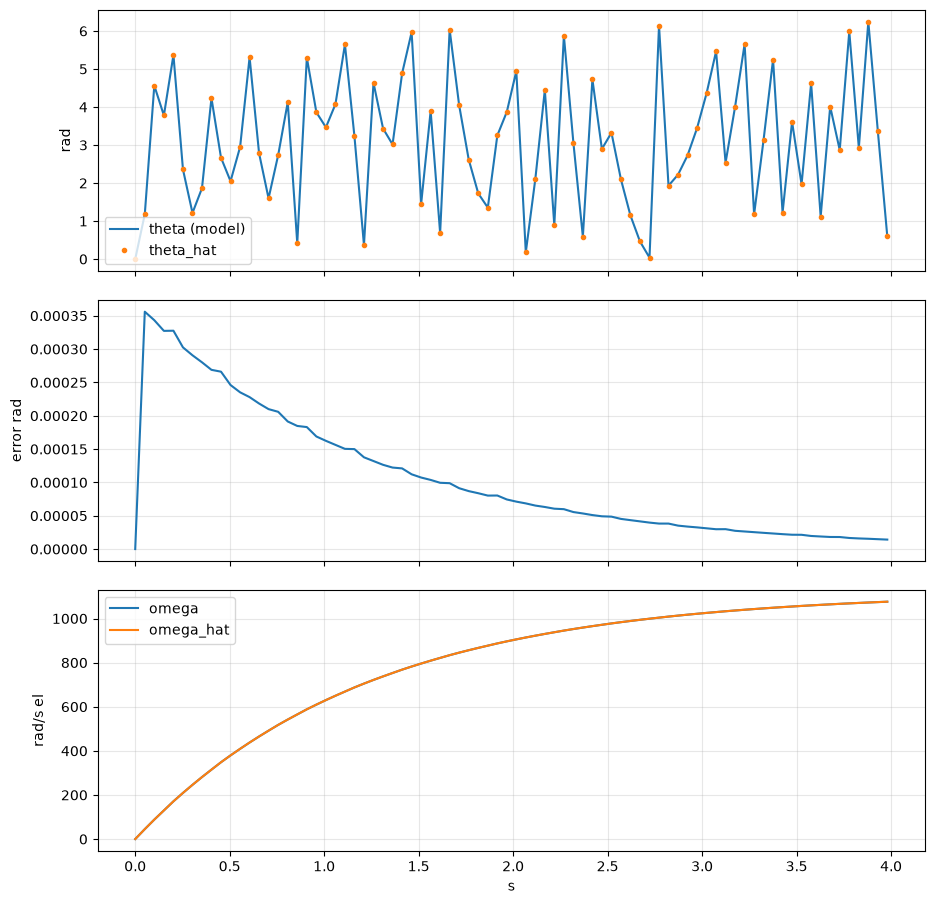

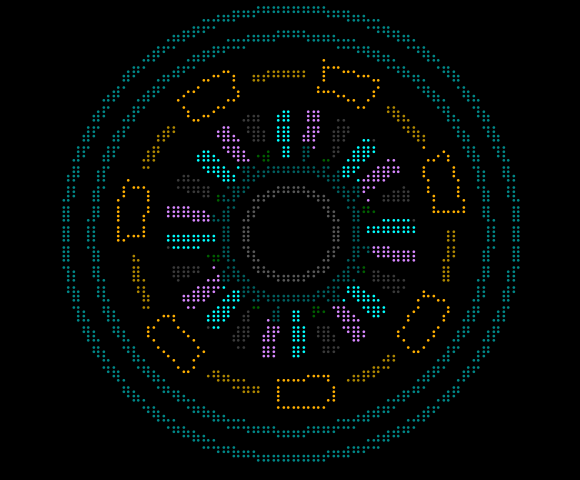

In [19]:
from IPython.display import display
from coaxial.draw import cross_section
from machine import ansi

t = [r[0] for r in spin]
fig, (angle, mid, bottom) = figure(rows=3, sharex=True)
angle.plot(t, [r[1] for r in spin], label='theta (model)')
angle.plot(t, [r[2] for r in spin], '.', label='theta_hat')
angle.set_ylabel('rad')
angle.legend()
mid.plot(t, [r[3] for r in spin])
mid.set_ylabel('error rad')
bottom.plot(t, [r[4] for r in spin], label='omega')
bottom.plot(t, [r[5] for r in spin], label='omega_hat')
bottom.set_ylabel('rad/s el')
bottom.set_xlabel('s')
bottom.legend()
show(fig)
pole_pairs = int(params['motor_pole_pairs'])
theta = spin[-1][1]
amps = tuple(0.05 * math.cos(theta - k * 2.0 * math.pi / 3.0) for k in range(3))
display(ansi.image(cross_section.render(math.degrees(theta) / pole_pairs, slots=24,
                                        poles=2 * pole_pairs, width=58, height=24,
                                        amps=amps, colour=True)))

## 13 The back-EMF chain beside the loop

Op 14: `drive_observer.c` beside the loop, driving nothing. `valid` false below the leak's corner. `error` is the chain minus the loop out of one reply. On the stand-in the chain is the C's Python mirror over a short window: its error and lambda are the mirror's, not the board's.

In [20]:
drive.model.reset()
drive.model.configure(j=2e-5, b=6e-5, load=0.0, noise=0.0)
drive.write(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.on('sensorless')
chain = []
for iq in (0.05, 0.15, 0.35, 0.60):
    drive.write(iq_ref=iq)
    settle = time.monotonic() + 3.0        # the rotor's j/b is 0.33 s
    while time.monotonic() < settle:
        drive.observers.read()             # the stand-in steps its chain only while asked
        time.sleep(0.02)
    t0 = time.monotonic()
    while time.monotonic() - t0 < 1.5:
        o = drive.observers.read()
        m = drive.model.read()
        chain.append((m['omega'], o['error'], m['error'], o['blend'], o['valid']))
        time.sleep(0.02)
last = drive.observers.read()
drive.off()
print({k: last[k] for k in ('valid', 'blend', 'blend_lo', 'blend_hi', 'wc')})
edges = [0.0, 500.0, 1200.0, 2500.0, 1e9]
print('%10s %8s %5s %11s %15s %7s'
      % ('rad/s el', 'rpm', 'n', 'loop deg', 'chain-loop deg', 'blend'))
for lo, hi in zip(edges, edges[1:]):
    band_rows = [r for r in chain if lo <= abs(r[0]) < hi]
    if not band_rows:
        continue
    speed = sum(abs(r[0]) for r in band_rows) / len(band_rows)
    print('%10.0f %8.0f %5d %11.2f %15.2f %7.2f'
          % (speed, speed / pole_pairs * 60.0 / math.tau, len(band_rows),
             deg_rms([mc.wrap(r[2]) for r in band_rows]),
             deg_rms([mc.wrap(r[1]) for r in band_rows]),
             sum(r[3] for r in band_rows) / len(band_rows)))
print('lambda   %.5f V.s carried, %.5f in the record'
      % (last['lambda_hat'], params['motor_lambda']))

{'valid': True, 'blend': 0.3695855755950473, 'blend_lo': 800.0, 'blend_hi': 3000.0, 'wc': 20.0}
  rad/s el      rpm     n    loop deg  chain-loop deg   blend
       277      377    63        0.00            1.59    0.00
       695      949    65        0.00            7.43    0.00
      1415     1931   127        0.00           24.03    0.28
lambda   0.00492 V.s carried, 0.00500 in the record


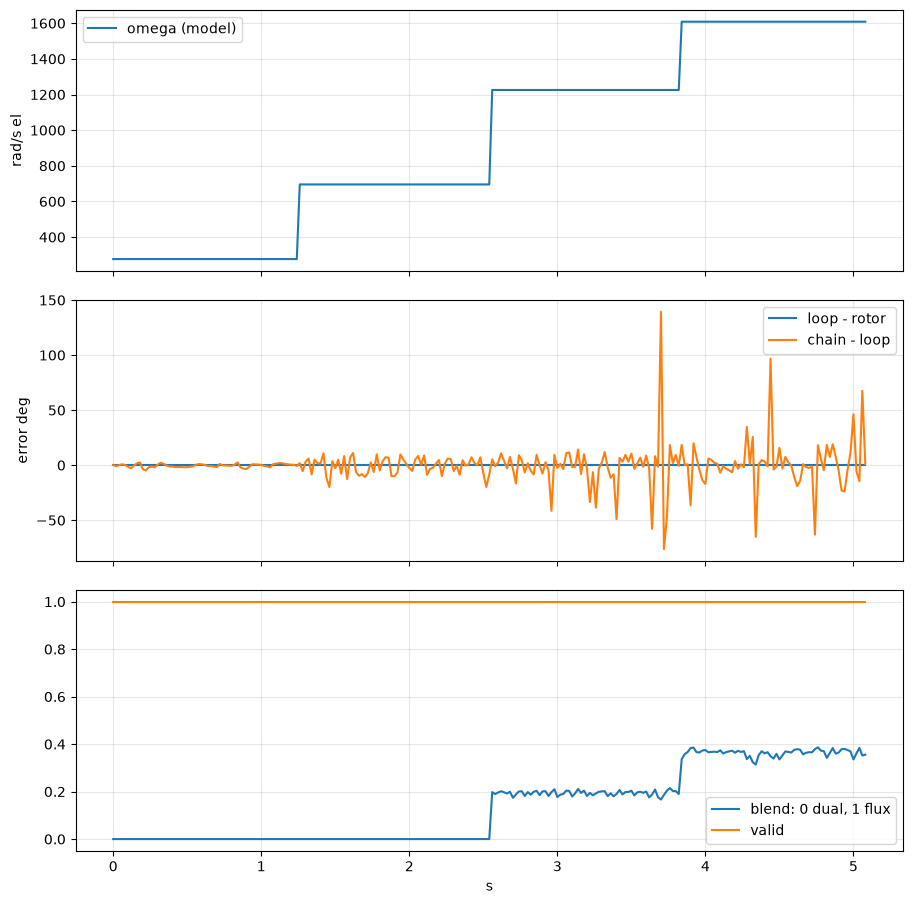

back on the converters: True


In [21]:
t = [i * 0.02 for i in range(len(chain))]
fig, (speed, mid, bottom) = figure(rows=3, sharex=True)
speed.plot(t, [r[0] for r in chain], label='omega (model)')
speed.set_ylabel('rad/s el')
speed.legend()
mid.plot(t, [math.degrees(mc.wrap(r[2])) for r in chain], label='loop - rotor')
mid.plot(t, [math.degrees(mc.wrap(r[1])) for r in chain], label='chain - loop')
mid.set_ylabel('error deg')
mid.legend()
bottom.plot(t, [r[3] for r in chain], label='blend: 0 dual, 1 flux')
bottom.plot(t, [1.0 if r[4] else 0.0 for r in chain], label='valid')
bottom.set_xlabel('s')
bottom.legend()
show(fig)
drive.model.reset()
print('back on the converters:', drive.configure(source='adc')['source'])

In [22]:
device.close()
print(device)

<Coaxial63100 Simulated closed SIMULATED>


## 14 Results

In [23]:
bands = {which: band_of(which) for which in ('smo', 'flux', 'blend')}
print('1.  two observers    sliding mode inside %.0f deg from %.0f to %.0f rpm, flux linkage from %.0f to %.0f, '
      'the blend from %.0f to %.0f'
      % (CRITERION_DEG, rpm(bands['smo'][0]), rpm(bands['smo'][1]), rpm(bands['flux'][0]),
         rpm(bands['flux'][1]), rpm(bands['blend'][0]), rpm(bands['blend'][1])))
print('2.  the second L     %.2f deg of bias at 100 A on the plain flux observer, %.1f %% of the torque'
      % (math.degrees(math.atan2((motor.lq - motor.ld) * 100.0, motor.lam)),
         100.0 * (1.0 - math.cos(math.atan2((motor.lq - motor.ld) * 100.0, motor.lam)))))
print('3.  five ranked      ' + ', '.join('%s %.1f to %.1f deg' % (
    n, min(g[n] for g in medians), max(g[n] for g in medians)) for n in RANKED))
w_gain, gain = max(table.items(), key=lambda item: min(median(item[1]['smo']), median(item[1]['flux']))
                   - median(item[1]['blend']))
print('4.  the blend        gains most at %.0f rad/s: %.1f deg against %.1f for the better single; '
      '%d cycles of headroom a period'
      % (w_gain, median(gain['blend']), min(median(gain['smo']), median(gain['flux'])),
         PERIOD_CYCLES - STEP_CYCLES))
print('5.  lambda from |psi| %.3f of the truth at %.0f rad/s with R 30 %% high, %.3f at %.0f'
      % (recovered[SPEEDS[-1]][1], SPEEDS[-1], recovered[SPEEDS[0]][1], SPEEDS[0]))
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = verified[verified.vdc == vdc]
    print('6.  the search       %2.0f V: bw_i %4.0f Hz, f_pll %3.0f Hz, v_inj %.3f, sigma_theta %.2f deg, '
          'trips %d of %d; back-EMF alone loses the rotor at %.0f rpm of %.0f'
          % (vdc, row.bw_i, row.f_pll, row.v_inj, math.degrees(sub.sigma_theta.mean()),
             int(sub.trip.sum()), len(sub), floor.loc[vdc, 'mean'], no_load_rpm(vdc, motor.lam)))
print('7.  operating point  APC20x10E: %.0f rpm and %.2f N.m at 23 V, %.0f rpm and %.2f N.m at 63 V, the 100 A rating'
      % (operating[23.0][1], operating[23.0][2], operating[63.0][1], operating[63.0][2]))
print('8.  the envelope     %.0f to %.0f rpm at 63 V; peak %.2f to %.2f N.m, continuous %.2f to %.2f N.m = %.0f %% of peak; '
      '%.2f s at 100 A from ambient'
      % (*top, *peak, *cont, 100.0 * cont[0] / peak[0], burst_s(100.0)))
print('9.  low saliency     %.2f A of HF current at 1.5, %.2f at 1.05; at 1 A of headroom 1.02 goes to %s'
      % (methods[1.5][0], methods[1.05][0], methods[1.02][2]))
print('10. the chain, 63 V  holds %.0f to %.0f rpm inside %.1f deg = %.1f %% of the torque; dual alone to %.0f rpm, '
      'plain flux from %.0f'
      % (grip['chain'][0], grip['chain'][1], grip['chain'][2], grip['chain'][3],
         grip['dual'][1], grip['flux'][0]))
errors = [abs(r[3]) for r in spin]
print('11. the model        rotor %.0f to %.0f rad/s electrical; observer error %.4f rad rms, worst %.4f (%.2f deg)'
      % (min(r[4] for r in spin), max(r[4] for r in spin),
         math.sqrt(sum(e * e for e in errors) / len(errors)), max(errors), math.degrees(max(errors))))
print('12. the step         %.1f us period, %d cycles at 475 MHz, exit %d of %d TIM1 ticks; '
      'virtual step sample %d, law %d, advance %d cycles'
      % (state['ts'] * 1e6, state['isr_cycles_max'], state['exit_ticks_max'], 2 * 2375,
         state['cycles']['sample'], state['cycles']['step'], state['cycles']['advance']))
valid = [abs(mc.wrap(r[1])) for r in chain if r[4]]
print('13. the chain on it  %.2f deg rms from the loop where valid, %d of %d; dual below %.0f rad/s, flux above %.0f; '
      'lambda %.5f carried of %.5f'
      % (deg_rms(valid) if valid else math.nan, len(valid), len(chain), last['blend_lo'],
         last['blend_hi'], last['lambda_hat'], params['motor_lambda']))

1.  two observers    sliding mode inside 20 deg from 14 to 1364 rpm, flux linkage from 136 to 1364, the blend from 14 to 1364
2.  the second L     18.66 deg of bias at 100 A on the plain flux observer, 5.3 % of the torque
3.  five ranked      dual 0.7 to 3.5 deg, smo 1.0 to 8.9 deg, flux 2.4 to 52.6 deg, eso 4.9 to 61.2 deg, luen 1.8 to 84.0 deg
4.  the blend        gains most at 1000 rad/s: 2.2 deg against 3.0 for the better single; 6578 cycles of headroom a period
5.  lambda from |psi| 0.994 of the truth at 2000 rad/s with R 30 % high, 0.317 at 20
6.  the search       23 V: bw_i 1187 Hz, f_pll  83 Hz, v_inj 0.200, sigma_theta 2.22 deg, trips 0 of 4; back-EMF alone loses the rotor at 31 rpm of 4151
6.  the search       43 V: bw_i  948 Hz, f_pll  50 Hz, v_inj 0.134, sigma_theta 2.72 deg, trips 0 of 4; back-EMF alone loses the rotor at 10 rpm of 7762
6.  the search       63 V: bw_i  948 Hz, f_pll  50 Hz, v_inj 0.134, sigma_theta 4.39 deg, trips 0 of 4; back-EMF alone loses the rotor at 

- Dual flux + PLL: 0.7 deg at 14 rpm; plain flux: 53.
- The chain: within 7.0 deg from 14 to 10 231 rpm at 63 V; back-EMF alone loses the rotor at 10-31 rpm.
- Peak 3.92-4.79 N.m at 100 A; continuous a quarter, thermal; 1.1 s at 100 A.
- Injection clears 10 dB to saliency 1.02.
- The step: exit at 2 921 of 4 750 TIM1 ticks here; 2 922 of 9 500 cycles on the board.

**Bench.** `isr_cycles_max` and `exit_ticks_max` first. With a motor: `drive.observers.read()['error']`; phase current `1/cos` of the angle error.

## References

* `host/coaxial/model/sensorless.py` - the five observers, `choose_injection` and `decide`
* `host/coaxial/model/blocks.py` - the current loop, the plant and the speed loop the search closes
* `host/tools/sim/montecarlo.py` - the firmware's C searched over the link sweep, one process per core
* `host/tests/test_drive_core.py` - the C held to the Python it was ported from, over drawn plants
* `drive/src/drive_observer.c` - the back-EMF chain the board runs beside the loop, op 14
* `host/coaxial/devices/drive.py` - device 10: `state`, `read` (the window), `model`, `observers`, `params` (the record)
* `host/coaxial/simulated/drive/` - the stand-in this ran on: the PMSM, and the chain stepped over a bounded window
* `docs/FINDINGS.md` - the caches were off: 10 040, 6 756 and 2 922 cycles a step